# 🌱 Suitability Modelling Steps

## 1️⃣ Define target species
- We write down the list of species we want to model.

## 2️⃣ Download and clean occurrences
- For each species:
  - We download occurrence points (e.g., from GBIF).
  - We clean the data:
    - Remove invalid or missing coordinates.
    - Remove points over the ocean.
    - Remove duplicates.
    - Optionally, filter to recent years.
- We save the cleaned occurrences as a dataframe with:  
  `species, lon, lat`.

## 3️⃣ Generate background (pseudo-absence) points
- We create random points across the study area.
- We assign them `presence = 0`.

## 4️⃣ Load environmental predictors
- We choose our predictors:
  - TerraClimate (monthly & flexible)  
  - or WorldClim (BIO1–BIO19, easy for SDMs).
- We load the raster files into Python.
- We stack them into a single dataset.

## 5️⃣ Extract predictor values at points
- At occurrence and background points, we extract the predictor values from the rasters.
- We combine everything into one dataframe with predictors + `presence` column.

## 6️⃣ Train a model per species
- For each species:
  - We fit a model using predictors and `presence`.
  - Example models:
    - Logistic regression
    - Random forest
    - Gradient boosting
    - Ensemble

## 7️⃣ Predict suitability over study area
- We use the trained model to predict suitability across the full raster grid.

## 8️⃣ Save and analyse results
- We save the predicted suitability map (e.g., GeoTIFF).
- Optionally:
  - We visualise the maps.
  - We overlay maps of multiple species.
  - We compute statistics like total suitable area, overlap, etc.


## 1️⃣ Define target species
let's for now just use those examples from the bachelor thesis


In [1]:
from utils_agroforestry import *
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd

# Load agroforestry composition tables
agroforest = {
    0: pd.read_csv("/Users/szelie/data/unu/agroforestry_systems/aguacate_vegetation.csv"),
    1: pd.read_csv("/Users/szelie/data/unu/agroforestry_systems/piso_verde_vegetation.csv"),
}


In [2]:
import pandas as pd

# ✅ Step 1: Define target species
# Assuming these are your two dataframes with species of interest:
# df1 and df2 already loaded

target_species = pd.concat([agroforest[0]['species'], agroforest[1]['species']]).dropna().unique()
print(f"🎯 Found {len(target_species)} target species.")



🎯 Found 50 target species.


2️⃣ Download and clean occurrences

For each species:
We download occurrence points (e.g., from GBIF).
We clean the data:
Remove invalid or missing coordinates.
Remove points over the ocean.
Remove duplicates.
Optionally, filter to recent years.
We save the cleaned occurrences as a dataframe with:
species, lon, lat.


In [84]:
agroforest[0]

,species,type,cover_ratio,quantity,height_min_m,height_max_m
0,Inga Fagifolia,1st tree,20.0,43,5.0,25.0
1,Mangifera Indica,1st tree,5.0,22,5.0,25.0
2,Roystonea Hispaniolana,1st tree,1.0,6,5.0,25.0
3,Didymopanax Morototoni,1st tree,1.0,5,5.0,25.0
4,Senna Spectabilis,1st tree,0.5,2,5.0,25.0
5,Musa _ Paradisiaca,2nd tree,35.0,52,2.0,5.0
6,Theobroma Cacao,2nd tree,20.0,45,2.0,5.0
7,Citrus _ Sinensis,2nd tree,2.5,11,2.0,5.0
8,Citrus _ Aurantium,2nd tree,2.5,10,2.0,5.0
9,Pimenta Racemosa,2nd tree,2.0,8,2.0,5.0


In [87]:
from pygbif import occurrences as gbif
import pandas as pd
import numpy as np
import time
import os

# 📋 Helper function
def clean_species_name(name):
    name = name.replace('_', ' ').replace('×', '').strip()
    name = ' '.join(name.split())
    parts = name.split()
    if len(parts) >= 2:
        genus = parts[0].capitalize()
        species = parts[1].lower()
        return f"{genus} {species}"
    return name

# 📋 Fetch all occurrences for a species in bbox
def fetch_species_in_bbox(species, wkt_bbox, max_records=None):
    all_results = []
    offset = 0
    batch_size = 300

    while True:
        res = gbif.search(
            scientificName=species,
            hasCoordinate=True,
            geometry=wkt_bbox,
            limit=batch_size,
            offset=offset
        )
        results = res.get("results", [])
        if not results:
            break
        # 🌟 keep only records >1960
        filtered = [r for r in results if r.get("year") and r["year"] > 1960]
        all_results.extend(filtered)

        offset += batch_size
        print(f"  📦 Fetched {offset} total | Kept {len(all_results)} after 1960 for {species}")

        if max_records and offset >= max_records:
            break
        time.sleep(0.5)
    return pd.json_normalize(all_results)

# --- load existing data or start fresh ---
if os.path.exists("occurrences_raw.parquet"):
    occ_raw = pd.read_parquet("occurrences_raw.parquet")
    if occ_raw.empty:
        already_fetched = set()
        print("🔄 Found existing file but it was empty — resetting already_fetched.")
    else:
        already_fetched = set(occ_raw['species_query'].unique())
        print(f"📄 Found existing data for {len(already_fetched)} species.")
else:
    occ_raw = pd.DataFrame()
    already_fetched = set()
    print("📄 No existing data found — starting fresh.")

all_records = []  # collect new records

# 📋 Bounding box for Central America
wkt_bbox = "POLYGON((-100 10, -77 10, -77 22, -100 22, -100 10))"

# --- fetch GBIF occurrences ---
for species_raw in target_species:
    species = clean_species_name(species_raw)
    if species in already_fetched:
        print(f"✅ Already fetched: {species}, skipping.")
        continue

    print(f"🌱 Fetching: {species}")
    try:
        records = fetch_species_in_bbox(species, wkt_bbox)
        if not records.empty:
            records["species_query"] = species
            all_records.append(records)
            already_fetched.add(species)

            # save progress
            occ_raw = pd.concat([occ_raw, records], ignore_index=True)
            occ_raw.to_parquet("occurrences_raw.parquet", index=False)
            print(f"💾 Saved progress: {len(already_fetched)} species so far.")
        else:
            print(f"⚠️ No results for: {species} in Central America after 1960")
    except Exception as e:
        print(f"❌ Failed for {species}: {e}")
    time.sleep(1)

if not occ_raw.empty:
    print(f"\n✅ Downloaded total: {len(occ_raw)} GBIF records (all >1960).")
else:
    print("⚠️ No records fetched.")

# --- load Excel file ---
print("\n📂 Loading Excel data…")
excel_path = "/Users/szelie/data/unu/occurrence_data-1.xlsx"
df_excel = pd.read_excel(excel_path, sheet_name="Data")

# --- clean Excel data ---
df_excel = df_excel.rename(columns={
    "species": "species_query",
    "lon": "decimalLongitude",
    "lat": "decimalLatitude"
})

# --- select useful columns ---
df_excel = df_excel[["species_query", "decimalLongitude", "decimalLatitude"] + 
                    [col for col in df_excel.columns if col not in ["species_query", "decimalLongitude", "decimalLatitude"]]]

print(f"✅ Loaded {len(df_excel)} records from Excel.")

# --- prepare GBIF data ---
if not occ_raw.empty:
    df_gbif = occ_raw[["species_query", "decimalLongitude", "decimalLatitude"] + 
                      [col for col in occ_raw.columns if col not in ["species_query", "decimalLongitude", "decimalLatitude"]]]
else:
    df_gbif = pd.DataFrame(columns=df_excel.columns)

# --- combine & drop duplicates ---
combined = pd.concat([df_gbif, df_excel], ignore_index=True)

before = len(combined)
combined = combined.drop_duplicates(subset=["species_query", "decimalLongitude", "decimalLatitude"])
after = len(combined)

print(f"\n🎉 Combined dataset: {after} records ({before-after} duplicates removed).")

# --- save combined ---
combined.to_parquet("occurrences_combined.parquet", index=False)
print(f"💾 Saved combined dataset to 'occurrences_combined.parquet'")


📄 Found existing data for 40 species.
🌱 Fetching: Inga fagifolia
⚠️ No results for: Inga fagifolia in Central America after 1960
✅ Already fetched: Mangifera indica, skipping.
✅ Already fetched: Roystonea hispaniolana, skipping.
✅ Already fetched: Didymopanax morototoni, skipping.
✅ Already fetched: Senna spectabilis, skipping.
✅ Already fetched: Musa paradisiaca, skipping.
✅ Already fetched: Theobroma cacao, skipping.
✅ Already fetched: Citrus sinensis, skipping.
✅ Already fetched: Citrus aurantium, skipping.
✅ Already fetched: Pimenta racemosa, skipping.
✅ Already fetched: Pouteria sapota, skipping.
✅ Already fetched: Carica papaya, skipping.
✅ Already fetched: Melicoccus bijugatus, skipping.
🌱 Fetching: Coffee arabica
⚠️ No results for: Coffee arabica in Central America after 1960
✅ Already fetched: Ananas comosus, skipping.
✅ Already fetched: Columnea sanguinea, skipping.
✅ Already fetched: Manihot esculenta, skipping.
✅ Already fetched: Kniphofia uvaria, skipping.
✅ Already fetche

In [31]:
len(occ_all)

147155

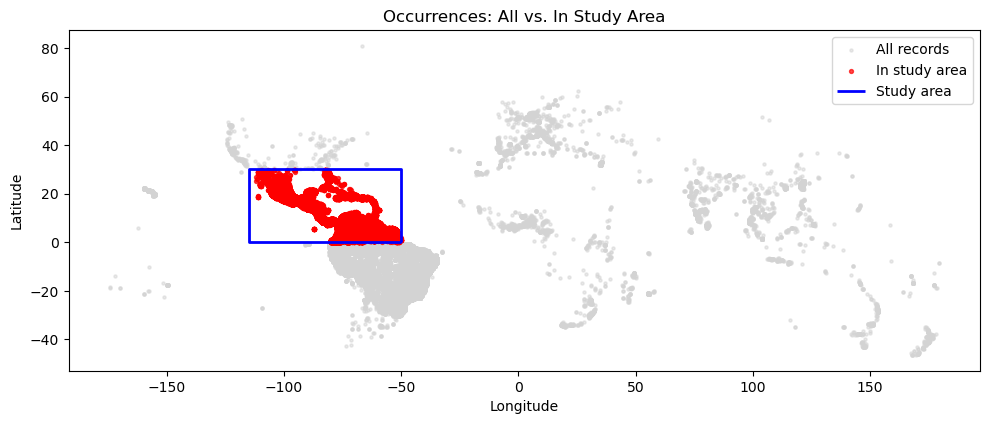

In [42]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box

# 📂 Load the data
occ_all = pd.read_parquet("occurrences_combined.parquet")

# 📍 Define bounding box (your study area)
lon_min = -115
lon_max = -50
lat_min = 0
lat_max = 30

# 🎯 Filter occurrences in study area
occ_study_area = occ_all[
    (occ_all['decimalLongitude'] >= lon_min) &
    (occ_all['decimalLongitude'] <= lon_max) &
    (occ_all['decimalLatitude'] >= lat_min) &
    (occ_all['decimalLatitude'] <= lat_max)
].copy()

# 🔷 Create GeoDataFrames
gdf_all = gpd.GeoDataFrame(
    occ_all,
    geometry=gpd.points_from_xy(occ_all.decimalLongitude, occ_all.decimalLatitude),
    crs="EPSG:4326"
)

gdf_study = gpd.GeoDataFrame(
    occ_study_area,
    geometry=gpd.points_from_xy(occ_study_area.decimalLongitude, occ_study_area.decimalLatitude),
    crs="EPSG:4326"
)

# 🎯 Define the study area polygon
study_area_poly = box(lon_min, lat_min, lon_max, lat_max)

# 🔷 Plot
fig, ax = plt.subplots(figsize=(10, 8))
gdf_all.plot(ax=ax, color="lightgray", label="All records", alpha=0.5, markersize=5)
gdf_study.plot(ax=ax, color="red", label="In study area", alpha=0.7, markersize=8)

# Plot the bounding box
gpd.GeoSeries([study_area_poly], crs="EPSG:4326").boundary.plot(
    ax=ax, color="blue", linewidth=2, label="Study area"
)

ax.set_title("Occurrences: All vs. In Study Area")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()


## 3️⃣ Generate background (pseudo-absence) points


In [37]:


import pandas as pd
import numpy as np

# 📍 Define bounding box for Mexico + Guatemala + Dominican Republic
lon_min = -100.98
lon_max = -77.02
lat_min = 13
lat_max = 21.98

# 🎯 Number of background points
n_background = 5000

# 🎲 Generate random points
np.random.seed(42)  # reproducible
bg_lons = np.random.uniform(lon_min, lon_max, n_background)
bg_lats = np.random.uniform(lat_min, lat_max, n_background)

background = pd.DataFrame({
    'lon': bg_lons,
    'lat': bg_lats,
    'presence': 0
})

print(f"✅ Generated {len(background)} background points.")
background.head()


✅ Generated 5000 background points.


,lon,lat,presence
0,-92.006019,16.534847,0
1,-78.200885,17.251452,0
2,-83.441425,20.673836,0
3,-86.636143,16.053239,0
4,-97.241793,20.809454,0


## 4️⃣ Load environmental predictors
- We choose our predictors:
  - TerraClimate (monthly & flexible)  
  - or WorldClim (BIO1–BIO19, easy for SDMs).
- We load the raster files into Python.
- We stack them into a single dataset.


In [39]:
import glob
import rioxarray as rxr
import xarray as xr

# 🌏 your folder with all 19 BIO files
raster_dir = "/Users/szelie/data/unu/wc2-2"

# 📂 find all .tif files for BIO variables
raster_files = sorted(glob.glob(f"{raster_dir}/wc2.1_2.5m_bio_*.tif"))

print(f"🗺️ Found {len(raster_files)} raster layers.")
assert len(raster_files) == 19, "Expected 19 BIO layers."

# 📦 load and stack
bio_layers = [rxr.open_rasterio(f, masked=True).squeeze() for f in raster_files]

# name each layer BIO1 … BIO19
for i, da in enumerate(bio_layers, 1):
    da.name = f"BIO{i}"

# merge into single xarray.Dataset
bio_stack = xr.merge(bio_layers)

print(bio_stack)

# optional: save as NetCDF if you want
# bio_stack.to_netcdf("/Users/szelie/data/unu/worldclim_bio_stack.nc")


🗺️ Found 19 raster layers.
<xarray.Dataset> Size: 3GB
Dimensions:      (x: 8640, y: 4320)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
    spatial_ref  int64 8B 0
Data variables: (12/19)
    BIO1         (y, x) float32 149MB ...
    BIO2         (y, x) float32 149MB ...
    BIO3         (y, x) float32 149MB ...
    BIO4         (y, x) float32 149MB ...
    BIO5         (y, x) float32 149MB ...
    BIO6         (y, x) float32 149MB ...
    ...           ...
    BIO14        (y, x) float32 149MB ...
    BIO15        (y, x) float32 149MB ...
    BIO16        (y, x) float32 149MB ...
    BIO17        (y, x) float32 149MB ...
    BIO18        (y, x) float32 149MB ...
    BIO19        (y, x) float32 149MB ...
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.166666030884
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMU

## 5️⃣ Extract predictor values at points
- At occurrence and background points, we extract the predictor values from the rasters.
- We combine everything into one dataframe with predictors + `presence` column.

In [43]:
import pandas as pd
import numpy as np


# 📋 Define study area bounding box

# 📋 Select predictors
selected_predictors = [
    "BIO2", "BIO3", "BIO8", "BIO9",
    "BIO13", "BIO14", "BIO15", "BIO18", "BIO19"
]

# 📋 Function to extract predictors at a point
def extract_predictors_at_point(lon, lat, stack):
    point = stack.sel(x=lon, y=lat, method="nearest")
    return [point[var].values.item() for var in selected_predictors]

# --- Presence points ---
occ_study_area = occ_raw[
    (occ_raw['decimalLongitude'] >= lon_min) &
    (occ_raw['decimalLongitude'] <= lon_max) &
    (occ_raw['decimalLatitude'] >= lat_min) &
    (occ_raw['decimalLatitude'] <= lat_max)
].copy()

occ_predictor_values = []
for _, row in occ_study_area.iterrows():
    lon = row['decimalLongitude']
    lat = row['decimalLatitude']
    vals = extract_predictors_at_point(lon, lat, bio_stack)
    occ_predictor_values.append(vals)

occ_predictor_df = pd.DataFrame(occ_predictor_values, columns=selected_predictors)
occ_with_predictors = pd.concat(
    [occ_study_area.reset_index(drop=True), occ_predictor_df],
    axis=1
)
occ_with_predictors["presence"] = 1
occ_with_predictors["species_query"] = occ_with_predictors["species_query"]  # keep original species

print(f"✅ Extracted predictors for {len(occ_with_predictors)} presence points.")

# --- Background points: uniform inside study area ---
n_background = len(occ_with_predictors) * 5  # adjust multiplier if needed
np.random.seed(42)

bg_lons = np.random.uniform(lon_min, lon_max, n_background)
bg_lats = np.random.uniform(lat_min, lat_max, n_background)

bg_coords = pd.DataFrame({"lon": bg_lons, "lat": bg_lats})

bg_predictor_values = []
valid_bg_coords = []

for _, row in bg_coords.iterrows():
    lon, lat = row["lon"], row["lat"]
    try:
        vals = extract_predictors_at_point(lon, lat, bio_stack)
        if all(np.isfinite(vals)):  # skip if NaNs
            bg_predictor_values.append(vals)
            valid_bg_coords.append((lon, lat))
    except:
        continue

bg_valid_df = pd.DataFrame(valid_bg_coords, columns=["lon", "lat"])
bg_predictor_df = pd.DataFrame(bg_predictor_values, columns=selected_predictors)

bg_with_predictors = pd.concat(
    [bg_valid_df.reset_index(drop=True), bg_predictor_df],
    axis=1
)
bg_with_predictors["presence"] = 0
bg_with_predictors["species_query"] = "background"

print(f"✅ Extracted predictors for {len(bg_with_predictors)} background points.")

# --- Combine ---
occ_final = occ_with_predictors[["decimalLongitude", "decimalLatitude"] + selected_predictors + ["presence", "species_query"]].rename(
    columns={"decimalLongitude": "lon", "decimalLatitude": "lat"}
)

bg_final = bg_with_predictors[["lon", "lat"] + selected_predictors + ["presence", "species_query"]]

data_all = pd.concat([occ_final, bg_final], ignore_index=True)

print(f"🎉 Final dataset: {len(data_all)} records.")
print(data_all["presence"].value_counts())
print(data_all["species_query"].value_counts())
print(data_all.head())


✅ Extracted predictors for 5972 presence points.
✅ Extracted predictors for 7668 background points.
🎉 Final dataset: 13640 records.
presence
0    7668
1    5972
Name: count, dtype: int64
species_query
background                  7668
Brosimum alicastrum          300
Roystonea hispaniolana       299
Melicoccus bijugatus         299
Simarouba glauca             296
Cecropia schreberiana        294
Paspalum botterii            292
Spondias mombin              289
Pouteria sapota              285
Didymopanax morototoni       281
Pimenta racemosa             278
Guazuma ulmifolia            261
Columnea sanguinea           198
Pinus occidentalis           195
Theobroma cacao              188
Borreria laevis              178
Ananas comosus               169
Carica papaya                153
Cajanus cajan                135
Ipomoea batatas              133
Arachis pintoi               131
Gliricidia sepium            131
Persea americana             123
Senna spectabilis            109
Citrus 

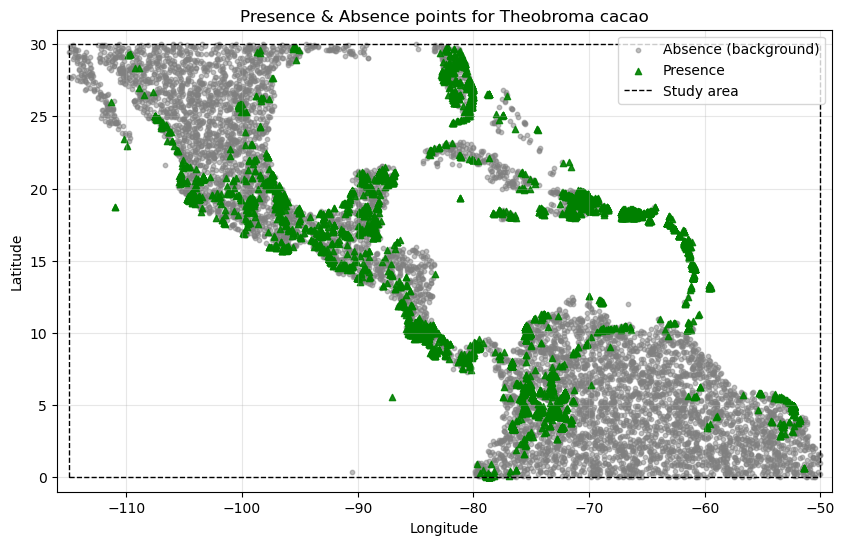

In [44]:
import matplotlib.pyplot as plt

# 📋 Separate presence & absence
presences = data_all[data_all["presence"] == 1]
absences  = data_all[data_all["presence"] == 0]

plt.figure(figsize=(10, 6))

# Background points (absence)
plt.scatter(
    absences["lon"], absences["lat"],
    color="grey", alpha=0.5, s=10, label="Absence (background)"
)

# Presence points
plt.scatter(
    presences["lon"], presences["lat"],
    color="green", alpha=0.9, s=20, marker='^', label="Presence"
)

# Study area bbox
plt.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    color="black", linestyle="--", linewidth=1, label="Study area"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Presence & Absence points for {species}")
plt.legend()
plt.xlim(lon_min - 1, lon_max + 1)
plt.ylim(lat_min - 1, lat_max + 1)
plt.grid(True, alpha=0.3)
plt.show()


In [45]:
# list of predictors
selected_predictors = [
    "BIO2", "BIO3", "BIO8", "BIO9",
    "BIO13", "BIO14", "BIO15", "BIO18", "BIO19"
]

# always keep these
keep_cols = selected_predictors + ["presence", "species_query"]

# keep only the necessary columns
data_clean = data_all[keep_cols].copy()

# drop rows with missing predictor values (optional but recommended)
data_clean = data_clean.dropna(subset=selected_predictors)

print(data_clean.head())
print(data_clean["presence"].value_counts())


        BIO2       BIO3   BIO8   BIO9      BIO13       BIO14      BIO15  \
0  27.568001  18.747334  520.0  195.0  48.851765  364.722321  32.231998   
1  22.211334  18.852667  428.0  182.0  72.490593  138.056427  27.628000   
2  28.012821  25.478205  406.0  145.0  67.094559  106.072395  31.100000   
3  27.459999  23.440666  587.0  113.0  68.643631  172.217117  33.152000   
4  27.459999  23.440666  587.0  113.0  68.643631  172.217117  33.152000   

       BIO18      BIO19  presence     species_query  
0  27.568001  18.747334         1  Mangifera indica  
1  21.283333  19.142666         1  Mangifera indica  
2  27.893589  25.787178         1  Mangifera indica  
3  27.357334  25.228666         1  Mangifera indica  
4  27.357334  25.228666         1  Mangifera indica  
presence
0    7668
1    5948
Name: count, dtype: int64


In [86]:
data_clean_to_save = data_clean[['lon','lat','species_query']]

,lon,lat,species_query
0,-80.163445,26.976393,Mangifera indica
1,-70.575120,19.120620,Mangifera indica
2,-61.856250,17.135085,Mangifera indica
3,-88.563708,18.074789,Mangifera indica
4,-88.562892,18.073619,Mangifera indica
...,...,...,...
13635,-88.236281,18.983432,background
13636,-100.864012,22.646437,background
13637,-65.139612,2.130840,background
13638,-97.635975,28.362120,background


📋 Columns in data_all: ['lon', 'lat', 'BIO2', 'BIO3', 'BIO8', 'BIO9', 'BIO13', 'BIO14', 'BIO15', 'BIO18', 'BIO19', 'presence', 'species_query']
✅ data_clean already has 'lon' & 'lat'
✅ Found 188 presence points for Theobroma cacao
✅ Selected 564 background points ≥ 0.5° from presences
📈 Records for Theobroma cacao: 752

Presence/Absence counts:
presence
0    564
1    188
Name: count, dtype: int64

Train size: 526, Test size: 226

🌳 Random Forest AUC on test set: 0.946

📋 Top predictors:
BIO9     0.172466
BIO3     0.133801
BIO15    0.129854
BIO14    0.126134
BIO8     0.122711
BIO13    0.112160
BIO19    0.086539
BIO2     0.061166
BIO18    0.055170
dtype: float64


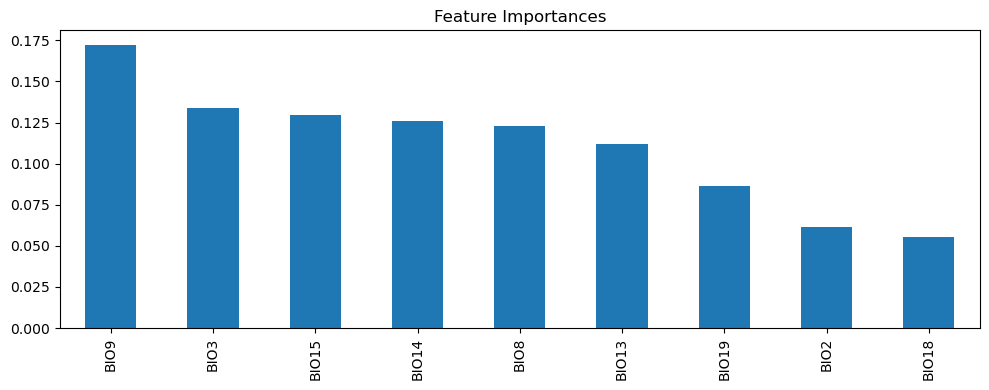

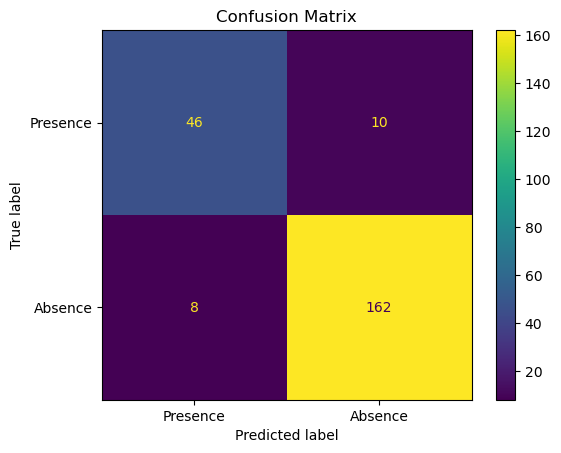

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

species = "Theobroma cacao"
min_distance_deg = 0.5  # minimum distance from presence (~10 km)

# 📋 Select predictors
selected_predictors = ["BIO2", "BIO3", "BIO8", "BIO9", "BIO13", "BIO14", "BIO15", "BIO18", "BIO19"]

# 🧹 Create data_clean with coordinates
print("📋 Columns in data_all:", list(data_all.columns))

if {"lon", "lat"}.issubset(data_all.columns):
    keep_cols = ["lon", "lat"] + selected_predictors + ["presence", "species_query"]
elif {"decimalLongitude", "decimalLatitude"}.issubset(data_all.columns):
    keep_cols = ["decimalLongitude", "decimalLatitude"] + selected_predictors + ["presence", "species_query"]
else:
    raise ValueError(
        f"🚨 No coordinates found in data_all columns: {list(data_all.columns)}"
)

data_clean = data_all[keep_cols].copy()

# 🧹 Ensure lon/lat columns are named correctly
if {"lon", "lat"}.issubset(data_clean.columns):
    print("✅ data_clean already has 'lon' & 'lat'")
elif {"decimalLongitude", "decimalLatitude"}.issubset(data_clean.columns):
    data_clean = data_clean.rename(columns={
        "decimalLongitude": "lon",
        "decimalLatitude": "lat"
    })
    print("🔄 Renamed 'decimalLongitude' & 'decimalLatitude' → 'lon' & 'lat'")
else:
    raise ValueError(
        f"🚨 Neither ['lon', 'lat'] nor ['decimalLongitude', 'decimalLatitude'] found in data_clean columns: {list(data_clean.columns)}"
)

# 📄 Select presence & background candidates
df_presence = data_clean[(data_clean["species_query"] == species) & (data_clean["presence"] == 1)].copy()
df_background_candidates = data_clean[data_clean["presence"] == 0].copy()

print(f"✅ Found {len(df_presence)} presence points for {species}")

# 📄 Build KDTree of presence points
presence_coords = df_presence[["lon", "lat"]].to_numpy()
tree = cKDTree(presence_coords)

# 📄 Background points — sample far enough
n_background = min(len(df_presence) * 3, len(df_background_candidates))
np.random.seed(42)

bg_candidates = df_background_candidates.sample(frac=1, random_state=42).reset_index(drop=True)

bg_selected = []
for idx, row in bg_candidates.iterrows():
    lon, lat = row["lon"], row["lat"]
    dist, _ = tree.query([lon, lat], k=1)
    if dist >= min_distance_deg:
        bg_selected.append(row)
    if len(bg_selected) >= n_background:
        break

df_background = pd.DataFrame(bg_selected).copy()
df_background["species_query"] = species

print(f"✅ Selected {len(df_background)} background points ≥ {min_distance_deg}° from presences")

# 🔗 Combine
df = pd.concat([df_presence, df_background], ignore_index=True)
print(f"📈 Records for {species}: {len(df)}")
print("\nPresence/Absence counts:")
print(df["presence"].value_counts())

if df["presence"].nunique() < 2:
    raise ValueError("🚨 Only one class present. Cannot train model.")

# 🚂 Split predictors & target
X = df.drop(columns=["species_query", "presence", "lon", "lat"])
y = df["presence"]

# 🚂 Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTrain size: {len(y_train)}, Test size: {len(y_test)}")

# 🌳 Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 📈 Predict
y_pred = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print(f"\n🌳 Random Forest AUC on test set: {auc:.3f}")

# 🔍 Feature importances
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n📋 Top predictors:")
print(importances)

importances.plot(kind="bar", figsize=(10,4), title="Feature Importances")
plt.tight_layout()
plt.show()

# 📊 Confusion matrix
y_pred_label = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_label, labels=[1,0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Presence", "Absence"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()


✅ Valid grid points in study area: 48004


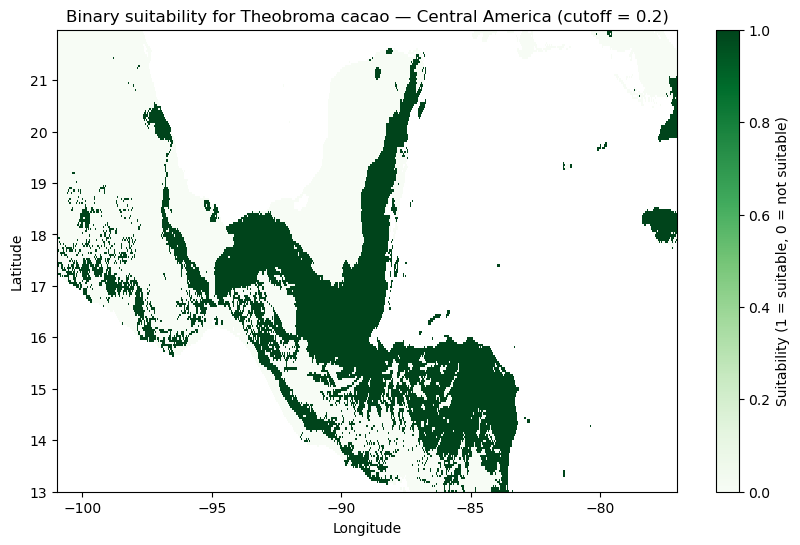

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 📋 Define study area bounding box
lon_min, lon_max = -100.98, -77.02
lat_min, lat_max = 13, 21.98

# 📋 Create prediction grid from bio_stack
xv, yv = np.meshgrid(bio_stack.x.values, bio_stack.y.values)

grid_df = pd.DataFrame({
    'lon': xv.ravel(),
    'lat': yv.ravel()
})

# add BIO variables
for var in bio_stack.data_vars:
    grid_df[var] = bio_stack[var].values.ravel()

# drop rows with missing data (e.g., oceans)
valid_grid_df = grid_df.dropna()

# 📋 Filter to study area
valid_grid_df = valid_grid_df[
    (valid_grid_df['lon'] >= lon_min) & (valid_grid_df['lon'] <= lon_max) &
    (valid_grid_df['lat'] >= lat_min) & (valid_grid_df['lat'] <= lat_max)
]

print(f"✅ Valid grid points in study area: {len(valid_grid_df)}")

# 📋 Select predictors matching training features
grid_X = valid_grid_df[X.columns]

# 📈 Predict suitability
suitability = clf.predict_proba(grid_X)[:, 1]

# 🗺️ Create empty array for suitability map
suitability_grid = np.full(bio_stack.BIO1.shape, np.nan)

# mark valid mask in study area
valid_mask = ~np.isnan(bio_stack.BIO1.values) & \
             (xv >= lon_min) & (xv <= lon_max) & \
             (yv >= lat_min) & (yv <= lat_max)

suitability_grid[valid_mask] = suitability

# 🔪 Apply threshold
threshold = 0.2
binary_suitability = np.full_like(suitability_grid, np.nan)
binary_suitability[valid_mask] = (suitability >= threshold).astype(int)

# 📊 Plot binary suitability map (study area)
plt.figure(figsize=(10, 6))
plt.pcolormesh(
    xv, yv, binary_suitability,
    cmap="Greens", shading='auto'
)
plt.colorbar(label='Suitability (1 = suitable, 0 = not suitable)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Binary suitability for Theobroma cacao — Central America (cutoff = {threshold})")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()


✅ Published map loaded: shape=(365, 576)
   min=0.0, max=255.0
⚠️ Detected NoData value in published: 255.0
✅ Overlapping valid pixels in study area: 44139


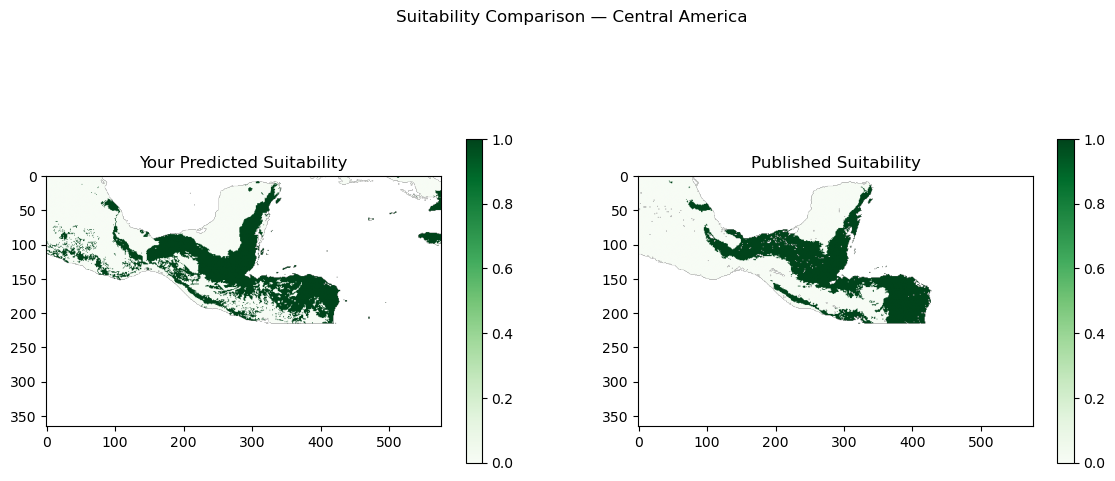

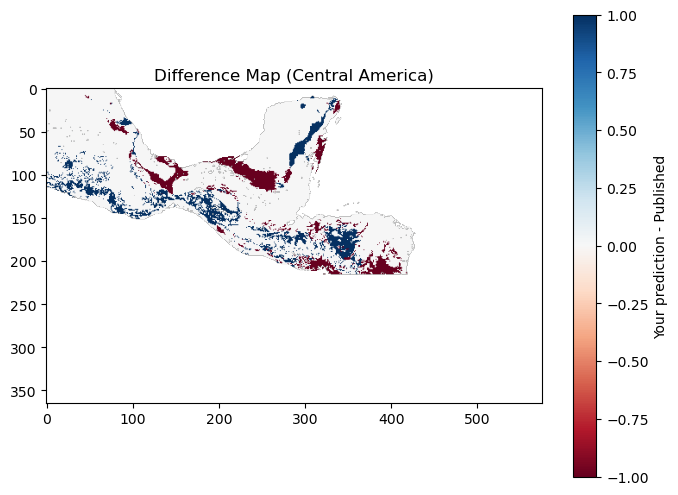

✅ RMSE (on overlapping study area): 0.4526
✅ Correlation (on overlapping study area): 0.5670
✅ Binary agreement (≥ 0.2) on overlapping study area: 79.52%


In [83]:
import rioxarray as rxr
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# 📋 Define study area bounding box
lon_min, lon_max = -100.98, -77.02
lat_min, lat_max = 13, 21.98

# 📂 Load published map
published_path = "/Users/szelie/data/unu/suitability/THEOCA_baseline.tif"
published = rxr.open_rasterio(published_path, masked=True).squeeze()
print(f"✅ Published map loaded: shape={published.shape}")
print(f"   min={published.min().values}, max={published.max().values}")

# 🔍 Detect NoData in published
unique_vals = np.unique(published.values[~np.isnan(published.values)])
suspect_nodata = unique_vals[-1]
if suspect_nodata >= 250:
    print(f"⚠️ Detected NoData value in published: {suspect_nodata}")
    published_masked = published.where(published != suspect_nodata)
else:
    published_masked = published

# 📄 Wrap your predicted suitability grid as xarray.DataArray
your_da = xr.DataArray(
    binary_suitability,
    dims=["y", "x"],
    coords={"y": bio_stack.y, "x": bio_stack.x},
    name="suitability"
).rio.write_crs(published.rio.crs)

# 🔷 Reproject your prediction to match published grid
your_resampled = your_da.rio.reproject_match(published)

# 🔷 Restrict both maps to Central America bbox
study_mask = (
    (published.x >= lon_min) & (published.x <= lon_max) &
    (published.y >= lat_min) & (published.y <= lat_max)
)

your_study = your_resampled.where(study_mask, np.nan)
published_study = published_masked.where(study_mask, np.nan)

# 🔷 Create overlap mask
valid_mask = ~np.isnan(your_study.values) & ~np.isnan(published_study.values)
print(f"✅ Overlapping valid pixels in study area: {np.sum(valid_mask)}")

# 🗺️ Plot side by side
fig, axs = plt.subplots(1, 2, figsize=(14,6))

im0 = axs[0].imshow(your_study.values, cmap="Greens", origin="upper")
axs[0].set_title("Your Predicted Suitability")
plt.colorbar(im0, ax=axs[0], shrink=0.7)

im1 = axs[1].imshow(published_study.values, cmap="Greens", origin="upper")
axs[1].set_title("Published Suitability")
plt.colorbar(im1, ax=axs[1], shrink=0.7)

plt.suptitle("Suitability Comparison — Central America")
plt.show()

# 🗺️ Plot difference map
diff = np.full_like(your_study.values, np.nan)
diff[valid_mask] = your_study.values[valid_mask] - published_study.values[valid_mask]

plt.figure(figsize=(8,6))
plt.imshow(diff, cmap="RdBu", origin="upper")
plt.colorbar(label="Your prediction - Published")
plt.title("Difference Map (Central America)")
plt.show()

# 📈 Compute RMSE & correlation
rmse = np.sqrt(np.nanmean((your_study.values[valid_mask] - published_study.values[valid_mask])**2))
corr = np.corrcoef(
    your_study.values[valid_mask].flatten(),
    published_study.values[valid_mask].flatten()
)[0,1]

print(f"✅ RMSE (on overlapping study area): {rmse:.4f}")
print(f"✅ Correlation (on overlapping study area): {corr:.4f}")

# 🔪 Compute binary agreement at threshold 0.2
threshold = 0.2
your_binary = (your_study.values >= threshold).astype(int)
published_binary = (published_study.values >= threshold).astype(int)

agreement = np.mean(your_binary[valid_mask] == published_binary[valid_mask])

print(f"✅ Binary agreement (≥ {threshold}) on overlapping study area: {agreement*100:.2f}%")


In [15]:
# 📋 Get coordinates
lon_min = float(published.x.min())
lon_max = float(published.x.max())
lat_min = float(published.y.min())
lat_max = float(published.y.max())

print(f"🌎 Published map bounding box:")
print(f"Longitude: {lon_min:.2f} to {lon_max:.2f}")
print(f"Latitude:  {lat_min:.2f} to {lat_max:.2f}")

🌎 Published map bounding box:
Longitude: -100.98 to -77.02
Latitude:  6.81 to 21.98


In [69]:
import subprocess
import os

# 📂 Paths
maxent_jar = "/Users/szelie/maxent.jar"
env_layers_dir = "/Users/szelie/data/unu/bioclim_asc_named"
output_dir = "/Users/szelie/data/unu/maxent_output"
presence_csv = "/Users/szelie/data/unu/occurrence_data.csv"

os.makedirs(output_dir, exist_ok=True)

print(f"✅ Using MaxEnt at: {maxent_jar}")
print(f"✅ Using presence points: {presence_csv}")
print(f"✅ Using environmental layers: {env_layers_dir}")
print(f"✅ Output will be saved to: {output_dir}")

# 🚀 Run MaxEnt
cmd = [
    "java", "-mx512m", "-jar", maxent_jar,
    f"environmentallayers={env_layers_dir}",
    f"samplesfile={presence_csv}",
    f"outputdirectory={output_dir}",
    "autorun",
    "randomseed",
    "randomtestpoints=25",  # use 25% of presence points for testing
    "replicates=1",
    "threads=2",
    "redoifexists"
]

print("🚀 Running MaxEnt …")
result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
    print(f"🎉 MaxEnt finished successfully! Outputs saved in:\n{output_dir}")
else:
    print(f"❌ MaxEnt failed. See error below:\n{result.stderr}")


✅ Using MaxEnt at: /Users/szelie/maxent.jar
✅ Using presence points: /Users/szelie/data/unu/occurrence_data.csv
✅ Using environmental layers: /Users/szelie/data/unu/bioclim_asc_named
✅ Output will be saved to: /Users/szelie/data/unu/maxent_output
🚀 Running MaxEnt …
🎉 MaxEnt finished successfully! Outputs saved in:
/Users/szelie/data/unu/maxent_output


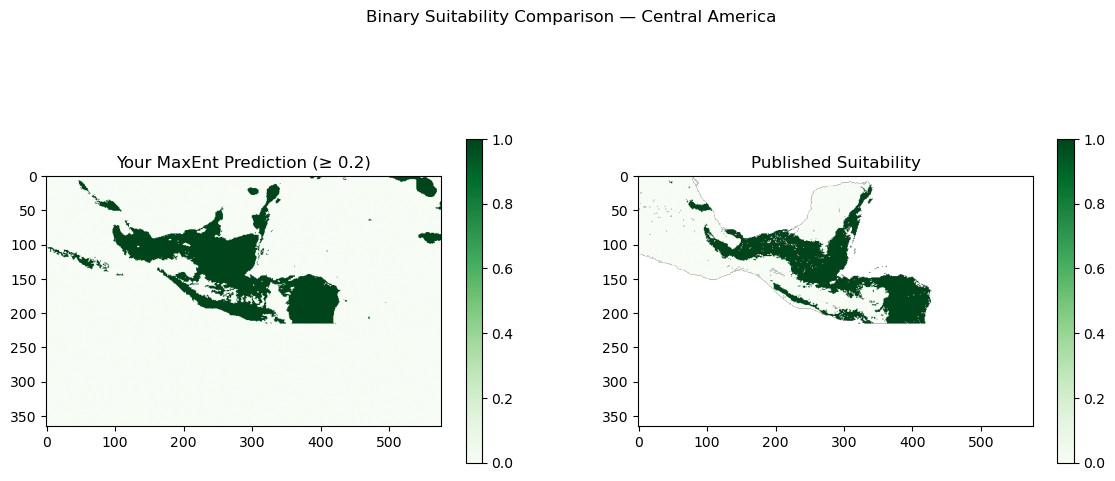

/Users/szelie/miniforge3/envs/climada_env/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


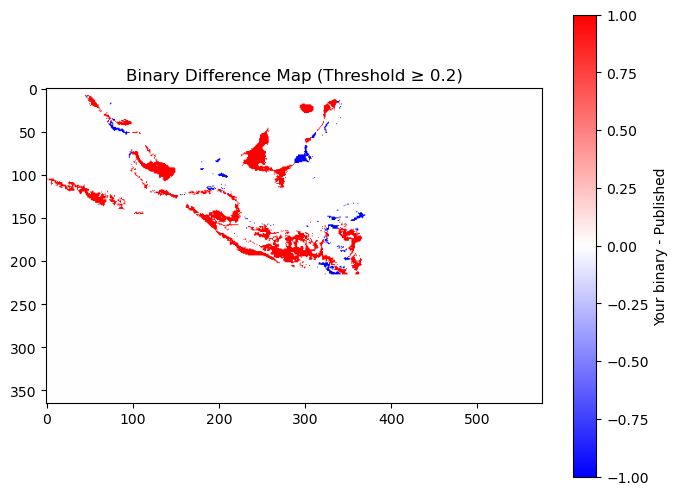

✅ Agreement (binary, threshold ≥ 0.2): 84.32%


In [76]:
# 🔪 Threshold your MaxEnt prediction at 0.2
threshold = 0.2
your_study_binary = xr.where(your_study >= threshold, 1, 0)

# 🗺️ Plot side by side (binary)
fig, axs = plt.subplots(1, 2, figsize=(14,6))

im0 = axs[0].imshow(your_study_binary.values, cmap="Greens", origin="upper")
axs[0].set_title(f"Your MaxEnt Prediction (≥ {threshold})")
plt.colorbar(im0, ax=axs[0], shrink=0.7)

im1 = axs[1].imshow(published_study.values, cmap="Greens", origin="upper")
axs[1].set_title("Published Suitability")
plt.colorbar(im1, ax=axs[1], shrink=0.7)

plt.suptitle("Binary Suitability Comparison — Central America")
plt.show()

# 🗺️ Plot binary difference map
diff_binary = np.full_like(your_study_binary.values, np.nan)
valid_mask = ~np.isnan(your_study_binary.values) & ~np.isnan(published_study.values)
diff_binary[valid_mask] = your_study_binary.values[valid_mask] - published_study.values[valid_mask]

plt.figure(figsize=(8,6))
plt.imshow(diff_binary, cmap="bwr", origin="upper")
plt.colorbar(label="Your binary - Published")
plt.title(f"Binary Difference Map (Threshold ≥ {threshold})")
plt.show()

# 📈 Compute binary agreement
agreement = np.mean(
    your_study_binary.values[valid_mask] == published_study.values[valid_mask]
)

print(f"✅ Agreement (binary, threshold ≥ {threshold}): {agreement*100:.2f}%")
